### 多状态图

In [1]:
from typing import Annotated

from operator import add

from langgraph.graph import StateGraph
from pydantic import BaseModel, Field


class CustomerState(BaseModel):
    logs: Annotated[list[str], add]
    cur_id: int = Field(..., description="当前节点ID")
    result: str = Field(default="", description="节点运行结果")
    query: str = Field(..., description="用户提问")


class InputState(BaseModel):
    cur_id: int = Field(..., description="当前节点ID")
    query: str = Field(..., description="用户提问")


class OutputState(BaseModel):
    output: str = Field(..., description="节点运行结果")


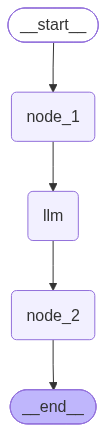

{'output': 'llm运行结果'}


In [2]:
from IPython.core.display import Image
from langgraph.constants import START, END


def node_1(state: InputState) -> CustomerState:
    return {
        "cur_id": state.cur_id,
        "logs": ["node1运行完毕"],
        "query": state.query,
    }


def llm(state: CustomerState) -> CustomerState:
    return {
        "logs": ["llm运行完毕"],
        "result": "llm运行结果",
    }


def node_2(state: CustomerState) -> OutputState:
    return {
        "output": state.result,
    }


builder = StateGraph(state_schema=CustomerState, input_schema=InputState, output_schema=OutputState)
builder.add_node(node_1)
builder.add_node(llm)
builder.add_node(node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "llm")
builder.add_edge("llm", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
result = graph.invoke({"cur_id": 1, "query": "你好"})
print(result)


### 私有状态（Private State）

**私有状态** 指的是：字段只定义在 `state_schema`（完整状态）里，
但**既不在 `input_schema`、也不在 `output_schema`** 中。
它只供图内部节点读写，调用方既不能传入、也看不到。

| 字段所在 schema | 调用方可传入 | 结果中可见 | 说明 |
| --- | --- | --- | --- |
| `input_schema` | 是 | - | 公开输入 |
| `output_schema` | - | 是 | 公开输出 |
| 仅 `state_schema` | 否（会被过滤） | 否 | **私有状态** |

典型用途：中间思考草稿、缓存、路由决策、内部消息等不需要对外暴露的数据。

- 输入侧：即使调用方多传私有字段，也会被 `input_schema` 过滤忽略；
- 输出侧：私有字段不会出现在 `invoke` 的返回值里；
- 私有字段同样支持 reducer（如 `add` 累加）；
- 建议给私有字段**默认值**，避免节点读取时尚未初始化；
- 命名上可用 `_` 前缀（约定，非强制）。


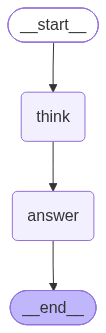

正常调用: {'result': '关于《你好》的回答'}
注入私有字段: {'result': '关于《你好》的回答'}
调试视角: {'query': '你好', 'scratchpad': ['分析问题：你好', '组织答案'], 'result': '关于《你好》的回答'}


In [3]:
from IPython.core.display import Image
from langgraph.constants import START, END


class FullState(BaseModel):
    query: str = Field(..., description="用户提问")
    # 私有状态：只存在于完整 state，不对外暴露；用 add 累加内部过程
    scratchpad: Annotated[list[str], add] = Field(
        default_factory=list, description="内部思考草稿（私有）"
    )
    result: str = Field(default="", description="最终结果")


class PrivateInput(BaseModel):
    query: str = Field(..., description="用户提问")   # 只暴露 query


class PrivateOutput(BaseModel):
    result: str = Field(..., description="最终结果")  # 只暴露 result


def think(state: FullState) -> FullState:
    # 写私有字段：内部记录思考过程
    return {"scratchpad": [f"分析问题：{state.query}"]}


def answer(state: FullState) -> FullState:
    return {
        "scratchpad": ["组织答案"],
        "result": f"关于《{state.query}》的回答",
    }


def build_private_graph(output_schema):
    builder = StateGraph(
        state_schema=FullState,       # 完整状态（含私有字段）
        input_schema=PrivateInput,    # 输入只接受 query
        output_schema=output_schema,  # 输出只返回公开字段
    )
    builder.add_node(think)
    builder.add_node(answer)
    builder.add_edge(START, "think")
    builder.add_edge("think", "answer")
    builder.add_edge("answer", END)
    return builder.compile()


private_graph = build_private_graph(PrivateOutput)
try:
    display(Image(private_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("跳过图形渲染：", e)
    print(private_graph.get_graph().draw_mermaid())

# 1) 调用方视角：只能传 query，返回只有 result；私有字段 scratchpad 不可见
print("正常调用:", private_graph.invoke({"query": "你好"}))

# 2) 输入里硬塞私有字段，会被 input_schema 过滤掉，不会生效
print("注入私有字段:", private_graph.invoke({"query": "你好", "scratchpad": ["外部注入"]}))

# 3) 调试时想看私有状态：换成完整 output_schema 即可
debug_graph = build_private_graph(FullState)
print("调试视角:", debug_graph.invoke({"query": "你好"}))


#### 小结

- 私有状态 = 只出现在 `state_schema`、被 `input_schema` / `output_schema` 挡在内外两侧的字段；
- 用它隔离**内部实现细节**，保持对外接口干净；
- 私有字段也能用 reducer 累加中间结果；
- 需要排查问题时，用一个 `output_schema=完整状态` 的调试图即可看到全部内部状态。


### 节点能同时访问全局状态和私有状态吗？

**可以。** 关键在于：

- 图的**完整状态是所有通道的并集**（公开 + 私有）；
- 节点**读取**什么，由它的输入 schema（`add_node(..., input_schema=...)` 或 `state` 参数的类型注解）决定；
- 节点**写入**什么不受限制——**可以写任意已注册的通道**。

所以只要让节点的输入 schema 同时包含公开字段和私有字段，
它就能在同一个节点里既读/写全局状态，又读/写私有状态。

| 节点 | input_schema | 能读 | 能写 |
| --- | --- | --- | --- |
| `node_1` | `OverallState` | 仅公开字段 | 任意通道 |
| `node_2` / `node_3` | `FullState` | 公开 + 私有 | 任意通道 |

> 注意：如果节点的输入 schema 里没有私有字段，直接访问它会报 `AttributeError`。


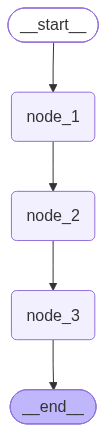

node_2 读到: foo='My name', bar=''
node_3 读到: foo='My name!', bar='My name is'
最终结果: {'user_input': 'My', 'foo': 'My name!', 'graph_output': 'My name is Lance'}


In [4]:
from IPython.core.display import Image
from langgraph.constants import START, END


class OverallState(BaseModel):
    user_input: str
    foo: str = ""
    graph_output: str = ""


class PrivateState(BaseModel):
    bar: str = ""          # 私有通道


class FullState(BaseModel):
    # 同时包含公开字段与私有字段，供需要“全访问”的节点使用
    user_input: str
    foo: str = ""
    graph_output: str = ""
    bar: str = ""


def node_1(state: OverallState) -> dict:
    # 只读取公开字段
    return {"foo": state.user_input + " name"}


def node_2(state: FullState) -> dict:
    # 同一个节点里同时读到公开字段 foo 和私有字段 bar
    print(f"node_2 读到: foo={state.foo!r}, bar={state.bar!r}")
    return {"foo": state.foo + "!", "bar": state.foo + " is"}


def node_3(state: FullState) -> dict:
    print(f"node_3 读到: foo={state.foo!r}, bar={state.bar!r}")
    return {"graph_output": state.bar + " Lance"}


full_access = StateGraph(
    OverallState,                 # 主 schema
    input_schema=OverallState,    # 图对外输入
    output_schema=OverallState,   # 图对外输出（隐藏私有通道 bar）
)

# 添加节点的时候加载私有状态
full_access.add_node("node_1", node_1, input_schema=OverallState)
full_access.add_node("node_2", node_2, input_schema=FullState)   # 公开 + 私有
full_access.add_node("node_3", node_3, input_schema=FullState)
full_access.add_edge(START, "node_1")
full_access.add_edge("node_1", "node_2")
full_access.add_edge("node_2", "node_3")
full_access.add_edge("node_3", END)

full_graph = full_access.compile()
try:
    display(Image(full_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("跳过图形渲染：", e)
    print(full_graph.get_graph().draw_mermaid())

# 私有通道 bar 参与了内部计算，但不会出现在最终输出里
print("最终结果:", full_graph.invoke({"user_input": "My"}))


#### 反例：输入 schema 里没有私有字段

如果节点的 `input_schema` 不含私有字段，它在运行时根本拿不到该字段，
直接访问会抛 `AttributeError`——这正好说明「私有」只对**读取方**生效。


In [ ]:
class OnlyPublic(BaseModel):
    foo: str = ""


def only_public_node(state: OnlyPublic) -> dict:
    try:
        _ = state.bar          # 私有字段不在输入 schema 中
        return {"foo": "读到了 bar"}
    except AttributeError as e:
        return {"foo": f"AttributeError: {e}"}


boundary = StateGraph(OverallState, input_schema=OverallState)
boundary.add_node("n", only_public_node, input_schema=OnlyPublic)
boundary.add_edge(START, "n")
boundary.add_edge("n", END)
print(boundary.compile().invoke({}))
